# Unidad 2 — Clase 4: Pilas (Stacks)

| Aspecto | Contenido |
|---|---|
| **Curso** | Estructuras de Datos y Algoritmos |
| **Unidad** | Unidad 2: Estructuras de Datos Lineales |
| **Tema** | Pilas (Stacks) - TDA, Implementaciones y Aplicaciones |
| **Duración** | 2 horas |
| **Prerequisitos** | Listas enlazadas, TDA, notación O(n), arreglos dinámicos |
| **Idioma código** | Python 3 con type hints y ABC |

---

## Objetivos de aprendizaje

Al finalizar esta clase, serás capaz de:
1. Comprender el TDA Pila y su estructura LIFO
2. Implementar pilas con arreglos dinámicos y listas enlazadas
3. Analizar la complejidad de operaciones de pila
4. Aplicar pilas a problemas clásicos (paréntesis, RPN, undo/redo)
5. Elegir la implementación adecuada según el contexto

## Mapa de la clase

| Sección | Tema | Duración | Página |
|---------|------|----------|--------|
| **1** | TDA Pila — ¿Qué es una Pila? | 15 min | Concepto fundamental LIFO |
| **2** | Implementación con Arreglo Dinámico | 25 min | Append y pop con análisis de amortización |
| **3** | Implementación con Lista Enlazada | 25 min | Nodos y referencias, O(1) estricto |
| **4** | Aplicaciones Clásicas | 30 min | Paréntesis, RPN, Undo/Redo |
| **5** | Análisis de Complejidad Comparativo | 10 min | Tabla y benchmarks |
| **6** | Ejercicios Prácticos | 15 min | Problemas y desafíos |

---

## Sección 1: TDA Pila — ¿Qué es una Pila? (15 min)

### Concepto Fundamental

Una **Pila** (Stack en inglés) es una estructura de datos **LIFO** (Last In, First Out):
- **Último en entrar, primero en salir**
- Piensa en una pila de platos: agregas platos por arriba, y sacas el de arriba (el más reciente)
- Analogía con el navegador: cada vez que visitamos una URL, se agrega al historial; atrás regresa a la anterior

### Operaciones Básicas

```
push(x)   → Inserta x en el tope
pop()     → Elimina y retorna el tope
peek()    → Retorna el tope sin eliminar
is_empty()→ Verdadero si no hay elementos
size()    → Cantidad de elementos
```

### Visualización ASCII

```
Estado inicial: []

push(10)  →   [10]       (tope = 10)
push(20)  →   [10, 20]   (tope = 20)
push(30)  →   [10, 20, 30] (tope = 30)  ← TOPE (arriba)

pop()     →   retorna 30
          →   [10, 20]   (tope = 20)

peek()    →   retorna 20 (sin eliminar)
          →   [10, 20]   (igual)
```

> **💡 Punto clave:** La pila es una abstracción que restringe el acceso a un solo extremo (tope). Esta restricción permite optimizar la estructura para casos de uso específicos como reversión, evaluación de expresiones, y gestión de llamadas a función.

In [ ]:
# Importar las implementaciones de pila
from pilas import PilaTDA, PilaArreglo, PilaEnlazada # Asegúrate de que estas clases estén definidas en pilas.py

print("="*60)
print("SECCIÓN 1: Demostración Básica de Pila")
print("="*60)

# Crear una pila con arreglo
p = PilaArreglo() ## Puedes cambiar a PilaEnlazada() para probar la otra implementación
print("\n1. Pila vacía:")
print(f"   {p}")
print(f"   is_empty() = {p.is_empty()}")
print(f"   size() = {p.size()}")

# Push de varios elementos
print("\n2. Después de push(10), push(20), push(30):")
p.push(10)
p.push(20)
p.push(30)
print(f"   {p}")
print(f"   size() = {p.size()}")

# Peek sin eliminar
print(f"\n3. peek() = {p.peek()} (sin eliminar)")
print(f"   {p}")

# Pop eliminando
print(f"\n4. pop() = {p.pop()}")
print(f"   {p}")
print(f"   size() = {p.size()}")

print(f"\n5. pop() = {p.pop()}")
print(f"   {p}")

# Manejo de error
print("\n6. Intentar pop de pila vacía:")
p.pop()  # size() es 1, falta un pop
try:
    p.pop()  # Ahora está vacía
    p.pop()  # Error aquí
except IndexError as e:
    print(f"   ✗ Error capturado: {e}")

print("\n✅ Sección 1 completada")

SECCIÓN 1: Demostración Básica de Pila

1. Pila vacía:
   PilaArreglo(vacía)
   is_empty() = True
   size() = 0

2. Después de push(10), push(20), push(30):
   PilaArreglo(tope → 30 → 20 → 10)
   size() = 3

3. peek() = 30 (sin eliminar)
   PilaArreglo(tope → 30 → 20 → 10)

4. pop() = 30
   PilaArreglo(tope → 20 → 10)
   size() = 2

5. pop() = 20
   PilaArreglo(tope → 10)

6. Intentar pop de pila vacía:
   ✗ Error capturado: pop de pila vacía

✅ Sección 1 completada


## Sección 2: Implementación con Arreglo Dinámico (25 min)

### Estructura Interna

En Python, una **lista** es un **arreglo dinámico**:
- Crece automáticamente cuando se llena
- El índice `-1` siempre apunta al último elemento (tope)
- `append()` agrega al final en O(1) amortizado
- `pop()` elimina del final en O(1) amortizado

### Mapeo de Operaciones

| Operación Pila | Arreglo Python | Complejidad |
|---|---|---|
| `push(x)` | `list.append(x)` | O(1) amortizado |
| `pop()` | `list.pop()` | O(1) amortizado |
| `peek()` | `list[-1]` | O(1) estricto |
| `size()` | `len(list)` | O(1) estricto |
| `is_empty()` | `len(list) == 0` | O(1) estricto |

### Diagrama de Memoria

```
Cuando push(10), push(20), push(30):

Índice:    0    1    2
Valor:  [10 , 20 , 30] ← tope en índice -1 (o 2)
               ↑
            peek() retorna 30

Capacidad interna puede ser > size() para evitar realocaciones frecuentes
(Python maneja esto internamente con un factor de crecimiento ~1.125x)
```

### Amortización

> **⚠️ Importante:** Aunque `append()` es O(1) amortizado, ocasionalmente realiza una copia completa del arreglo cuando necesita crecer. En contextos hard-real-time esto puede ser problemático, pero para la mayoría de aplicaciones es excelente.

In [2]:
print("\n" + "="*60)
print("SECCIÓN 2: Implementación con Arreglo")
print("="*60)

# Mostrar el código de PilaArreglo
print("\n1. Estructura de PilaArreglo:")
print("""
class PilaArreglo(PilaTDA):
    def __init__(self) -> None:
        self.__datos: list = []  # Arreglo dinámico privado

    def push(self, item: Any) -> None:
        self.__datos.append(item)  # O(1) amortizado

    def pop(self) -> Any:
        if self.is_empty():
            raise IndexError("pop de pila vacía")
        return self.__datos.pop()  # O(1) amortizado

    def peek(self) -> Any:
        if self.is_empty():
            raise IndexError("peek de pila vacía")
        return self.__datos[-1]  # O(1) estricto

    def size(self) -> int:
        return len(self.__datos)  # O(1) estricto
""")

# Demostración paso a paso
print("\n2. Demostración paso a paso:")
p = PilaArreglo()
print(f"\nEstado inicial: {p}")
print(f"   size() = {p.size()}, is_empty() = {p.is_empty()}")

valores = [100, 200, 300, 400, 500]
for v in valores:
    p.push(v)
    print(f"\nDespués push({v}):")
    print(f"   {p}")
    print(f"   size() = {p.size()}")

print(f"\nAhora peek() = {p.peek()} (sin eliminar)")
print(f"   {p}")

print(f"\nAhora pop():")
for i in range(3):
    valor = p.pop()
    print(f"   pop() retorna {valor} → {p} (size={p.size()})")

print("\n✅ Sección 2 - implementación completada")


SECCIÓN 2: Implementación con Arreglo

1. Estructura de PilaArreglo:

class PilaArreglo(PilaTDA):
    def __init__(self) -> None:
        self.__datos: list = []  # Arreglo dinámico privado

    def push(self, item: Any) -> None:
        self.__datos.append(item)  # O(1) amortizado

    def pop(self) -> Any:
        if self.is_empty():
            raise IndexError("pop de pila vacía")
        return self.__datos.pop()  # O(1) amortizado

    def peek(self) -> Any:
        if self.is_empty():
            raise IndexError("peek de pila vacía")
        return self.__datos[-1]  # O(1) estricto

    def size(self) -> int:
        return len(self.__datos)  # O(1) estricto


2. Demostración paso a paso:

Estado inicial: PilaArreglo(vacía)
   size() = 0, is_empty() = True

Después push(100):
   PilaArreglo(tope → 100)
   size() = 1

Después push(200):
   PilaArreglo(tope → 200 → 100)
   size() = 2

Después push(300):
   PilaArreglo(tope → 300 → 200 → 100)
   size() = 3

Después push(400):
   

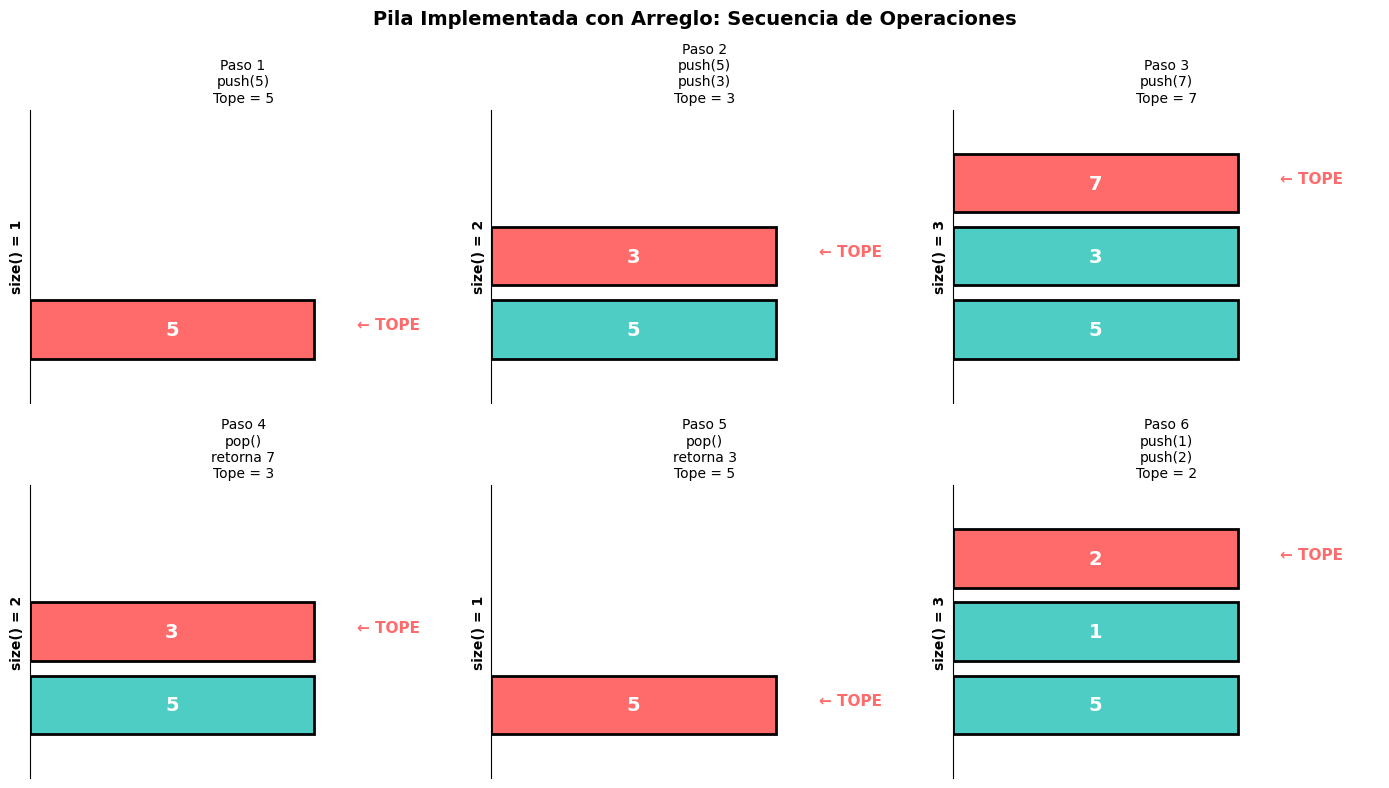

✅ Sección 2 - visualización completada


In [3]:
import matplotlib.pyplot as plt
import numpy as np

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Visualización: Estado de Pila con Arreglo
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Pila Implementada con Arreglo: Secuencia de Operaciones', fontsize=14, fontweight='bold')

# Datos para cada paso
pasos = [
    ([5], "push(5)", "Tope = 5"),
    ([5, 3], "push(5)\npush(3)", "Tope = 3"),
    ([5, 3, 7], "push(7)", "Tope = 7"),
    ([5, 3], "pop()\nretorna 7", "Tope = 3"),
    ([5], "pop()\nretorna 3", "Tope = 5"),
    ([5, 1, 2], "push(1)\npush(2)", "Tope = 2"),
]

for idx, (ax, (valores, operacion, nota)) in enumerate(zip(axes.flat, pasos)):
    # Crear barras
    y_pos = np.arange(len(valores))
    colores = ['#FF6B6B' if i == len(valores) - 1 else '#4ECDC4' for i in range(len(valores))]
    
    ax.barh(y_pos, [1]*len(valores), color=colores, edgecolor='black', linewidth=2)
    
    # Etiquetas
    for i, v in enumerate(valores):
        ax.text(0.5, i, str(v), ha='center', va='center', fontsize=14, fontweight='bold', color='white')
    
    # Marcador de tope
    if valores:
        ax.text(1.15, len(valores)-1, '← TOPE', fontsize=11, fontweight='bold', color='#FF6B6B')
    
    ax.set_xlim(0, 1.5)
    ax.set_ylim(-1, max(3, len(valores)))
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_ylabel(f"size() = {len(valores)}", fontsize=10, fontweight='bold')
    ax.set_title(f"Paso {idx+1}\n{operacion}\n{nota}", fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

plt.tight_layout()
plt.show()

print("✅ Sección 2 - visualización completada")

## Sección 3: Implementación con Lista Enlazada (25 min)

### Estructura con Nodos

Una lista enlazada usa **nodos** independientes conectados por referencias:

```
Clase _Nodo:
    dato: Any       → Valor almacenado
    siguiente: _Nodo | None  → Referencia al próximo nodo

PilaEnlazada:
    __tope: _Nodo | None   → Apunta al nodo del tope
    __tam: int              → Contador de elementos (O(1) size())
```

### Diagrama de la Cadena

```
push(10) → push(20) → push(30):

__tope apunta aquí ↓
┌─────┬───┐     ┌─────┬───┐     ┌─────┬────┐
│ 30  │ ──┼────→│ 20  │ ──┼────→│ 10  │ None│
└─────┴───┘     └─────┴───┘     └─────┴────┘
  ↑ TOPE          (segundo)       (tercero)

pop() retorna 30, __tope se mueve a nodo(20)
```

### Ventajas vs Arreglo

| Característica | Arreglo | Enlazada |
|---|---|---|
| **push** | O(1) amortizado | O(1) estricto |
| **pop** | O(1) amortizado | O(1) estricto |
| **Realocación** | Ocasional, copia completa | Nunca |
| **Localidad caché** | Excelente (contiguo) | Pobre (disperso) |
| **Uso de memoria** | Menos (cuando compacta) | Más (por punteros) |
| **Hard real-time** | Problemático | Apto |

> **💡 Dato:** Aunque enlazada es O(1) estricto, en práctica el arreglo suele ser más rápido por caché. Enlazada brilla en sistemas con restricciones de tiempo real duro.

In [ ]:
print("\n" + "="*60)
print("SECCIÓN 3: Implementación con Lista Enlazada")
print("="*60)

# Mostrar estructura
print("\n1. Estructura de nodos:")
print("""
class _Nodo:
    def __init__(self, dato: Any, siguiente: '_Nodo | None' = None):
        self.dato = dato
        self.siguiente = siguiente

class PilaEnlazada(PilaTDA):
    def __init__(self):
        self.__tope: _Nodo | None = None  # Apunta al nodo superior
        self.__tam: int = 0                # Contador para O(1) size()

    def push(self, item: Any) -> None:
        # Crear nuevo nodo con referencia al actual tope
        self.__tope = _Nodo(item, self.__tope)
        self.__tam += 1

    def pop(self) -> Any:
        if self.is_empty():
            raise IndexError("pop de pila vacía")
        valor = self.__tope.dato
        self.__tope = self.__tope.siguiente  # Avanzar al siguiente
        self.__tam -= 1
        return valor

    def peek(self) -> Any:
        if self.is_empty():
            raise IndexError("peek de pila vacía")
        return self.__tope.dato
""")

# Demostración
print("\n2. Demostración de PilaEnlazada:")
p_enl = PilaEnlazada()
print(f"\nEstado inicial: {p_enl}")
print(f"   is_empty() = {p_enl.is_empty()}, size() = {p_enl.size()}")

valores_2 = [10, 20, 30, 40]
for v in valores_2:
    p_enl.push(v)
    print(f"\nDespués push({v}):")
    print(f"   {p_enl}")
    print(f"   size() = {p_enl.size()}")

print(f"\n3. Operaciones de acceso:")
print(f"   peek() = {p_enl.peek()} (tope, sin eliminar)")
print(f"   {p_enl}")

print(f"\n4. Eliminaciones (pop):")
for i in range(2):
    v = p_enl.pop()
    print(f"   pop() retorna {v} → {p_enl} (size={p_enl.size()})")

print("\n✅ Sección 3 - implementación completada")

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Visualización: Lista Enlazada para Pila
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Pila Implementada con Lista Enlazada', fontsize=14, fontweight='bold')

# Eje 1: Estado con 3 nodos
ax1 = axes[0]
ax1.set_xlim(-0.5, 10)
ax1.set_ylim(-1, 5)
ax1.axis('off')
ax1.set_title('Estado: push(30), push(20), push(10)', fontsize=12, fontweight='bold')

# Dibujar __tope → apunta aquí
ax1.text(-0.3, 3.5, '__tope →', fontsize=11, fontweight='bold', ha='right')

# Nodo 1 (TOPE = 10)
node1_x, node1_y = 0, 3
box1 = FancyBboxPatch((node1_x-0.6, node1_y-0.4), 1.2, 0.8, boxstyle="round,pad=0.05",
                       edgecolor='red', facecolor='#FFE5E5', linewidth=2)
ax1.add_patch(box1)
ax1.text(node1_x, node1_y, '10', fontsize=12, fontweight='bold', ha='center', va='center')
ax1.text(node1_x+0.8, node1_y, '▶', fontsize=12, color='red')

# Flecha nodo 1 → nodo 2
arrow1 = FancyArrowPatch((node1_x+0.7, node1_y), (node1_x+1.3, node1_y),
                        arrowstyle='->', mutation_scale=20, color='red', linewidth=2)
ax1.add_patch(arrow1)

# Nodo 2 (20)
node2_x = node1_x + 2
box2 = FancyBboxPatch((node2_x-0.6, node1_y-0.4), 1.2, 0.8, boxstyle="round,pad=0.05",
                       edgecolor='blue', facecolor='#E5F5FF', linewidth=2)
ax1.add_patch(box2)
ax1.text(node2_x, node1_y, '20', fontsize=12, fontweight='bold', ha='center', va='center')
ax1.text(node2_x+0.8, node1_y, '▶', fontsize=12, color='blue')

# Flecha nodo 2 → nodo 3
arrow2 = FancyArrowPatch((node2_x+0.7, node1_y), (node2_x+1.3, node1_y),
                        arrowstyle='->', mutation_scale=20, color='blue', linewidth=2)
ax1.add_patch(arrow2)

# Nodo 3 (30)
node3_x = node2_x + 2
box3 = FancyBboxPatch((node3_x-0.6, node1_y-0.4), 1.2, 0.8, boxstyle="round,pad=0.05",
                       edgecolor='green', facecolor='#E5FFE5', linewidth=2)
ax1.add_patch(box3)
ax1.text(node3_x, node1_y, '30', fontsize=12, fontweight='bold', ha='center', va='center')
ax1.text(node3_x+0.8, node1_y, '✗', fontsize=12, color='green')

ax1.text(node3_x+1.2, node1_y, 'None', fontsize=10, style='italic', color='green')

# Etiquetas
ax1.text(node1_x, node1_y-1.2, 'TOPE (primero)', fontsize=10, ha='center', color='red', fontweight='bold')
ax1.text(node2_x, node1_y-1.2, 'segundo', fontsize=9, ha='center', color='blue')
ax1.text(node3_x, node1_y-1.2, 'tercero', fontsize=9, ha='center', color='green')

# Información
ax1.text(5.5, 4.2, '__tam = 3', fontsize=11, bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))
ax1.text(5.5, 3.7, 'size() = 3', fontsize=11, bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))

# Eje 2: Comparación de complejidad
ax2 = axes[1]
operaciones = ['push', 'pop', 'peek', 'size']
indices = range(len(operaciones))
complejidad_arreglo = [1, 1, 1, 1]  # O(1) pero amortizado
complejidad_enlazada = [1, 1, 1, 1]  # O(1) estricto

width = 0.35
ax2.bar([i - width/2 for i in indices], complejidad_arreglo, width, label='Arreglo (amortizado)', color='#4ECDC4')
ax2.bar([i + width/2 for i in indices], complejidad_enlazada, width, label='Enlazada (estricto)', color='#95E1D3')

ax2.set_ylabel('Complejidad (O(1))', fontsize=11, fontweight='bold')
ax2.set_title('Complejidad de Operaciones', fontsize=12, fontweight='bold')
ax2.set_xticks(indices)
ax2.set_xticklabels(operaciones)
ax2.set_ylim(0, 1.5)
ax2.legend()
ax2.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print("✅ Sección 3 - visualización completada")

## Sección 4: Aplicaciones Clásicas de Pilas (30 min)

Las pilas son fundamentales para resolver problemas que requieren **reversión de orden** o **análisis de estructura**.

---

### Aplicación 1: Validador de Paréntesis Balanceados (10 min)

#### Problema
Determinar si una expresión tiene paréntesis, corchetes y llaves **correctamente balanceados**.

**Válidos:** `(a + b)`, `[x * (y + z)]`, `{if (x > 0)}`

**Inválidos:** `(a + b]`, `((x)`, `{y]}`

#### Algoritmo
1. Recorrer cada carácter
2. Si es apertura `( [ {`: hacer `push(carácter)`
3. Si es cierre `) ] }`: hacer `pop()` y verificar que coincida
4. Paréntesis balanceados = pila vacía al final y sin errores

**Complejidad:** O(n) — una pasada, O(1) por carácter

---

### Aplicación 2: Evaluador de Notación Polaca Inversa (RPN) (10 min)

#### Concepto
Notación Polaca Inversa (Reverse Polish Notation): operadores van **después** de operandos.

| Notación Infiija | RPN (Postfija) | Resultado |
|---|---|---|
| `3 + 4` | `3 4 +` | 7 |
| `(3 + 4) * 5` | `3 4 + 5 *` | 35 |
| `2 * 3 + 4` | `2 3 * 4 +` | 10 |

#### Algoritmo
1. Recorrer tokens de izquierda a derecha
2. Si es número: `push(número)`
3. Si es operador: `pop()` dos operandos, operar, `push(resultado)`
4. Resultado final: último `pop()`

**Complejidad:** O(n) — cada token se procesa una vez

---

### Aplicación 3: Sistema de Undo/Redo (10 min)

#### Idea
Mantener **dos pilas**:
- **Pila de Undo:** acciones ejecutadas
- **Pila de Redo:** acciones deshechas

#### Ejemplo
```
Usuario escribe "Hola" → Undo: [Hola]
Usuario escribe " Mundo" → Undo: [Hola, " Mundo"]
Usuario hace Undo → Undo: [Hola], Redo: [" Mundo"]
Usuario hace Redo → Undo: [Hola, " Mundo"], Redo: []
Usuario escribe "!" → Undo: [Hola, " Mundo", "!"], Redo: [] (pila redo vacía)
```

#### Operaciones
- **Hacer acción:** `push` a Undo, vaciar Redo
- **Undo:** `pop` de Undo, `push` a Redo
- **Redo:** `pop` de Redo, `push` a Undo

In [ ]:
print("\n" + "="*60)
print("SECCIÓN 4: Aplicaciones Clásicas")
print("="*60)

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# APLICACIÓN 1: Validador de Paréntesis
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

from pilas import PilaArreglo

def balanceado(expresion: str) -> bool:
    """
    Verifica si paréntesis, corchetes y llaves están balanceados.
    
    Parámetros:
        expresion: cadena que puede contener caracteres y símbolos
    
    Retorna:
        True si están balanceados, False en caso contrario
    
    Complejidad: O(n) donde n es la longitud de la expresión
    """
    p = PilaArreglo()
    pares = {'(': ')', '[': ']', '{': '}'}
    apertura = set(pares.keys())
    cierre = set(pares.values())
    
    for char in expresion:
        if char in apertura:
            p.push(char)
        elif char in cierre:
            if p.is_empty():
                return False  # Cierre sin apertura
            tope = p.pop()
            if pares[tope] != char:
                return False  # Pareja incorrecta
    
    return p.is_empty()  # Debe estar vacía al final

# Pruebas
print("\n📋 APLICACIÓN 1: Validador de Paréntesis Balanceados")
print("─" * 60)

test_cases = [
    ("(a + b)", True),
    ("[x * (y + z)]", True),
    ("{ if (x > 0) }", True),
    ("((()))", True),
    ("(a + b]", False),
    ("((x)", False),
    ("{y]}", False),
    ("(([]))", True),
    ("([)]]", False),
]

for expr, esperado in test_cases:
    resultado = balanceado(expr)
    estado = "✓" if resultado == esperado else "✗"
    print(f"{estado} balanceado('{expr}') = {resultado}")

print("\n✅ Aplicación 1 completada")

In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# APLICACIÓN 2: Evaluador RPN (Reverse Polish Notation)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def evaluar_rpn(expresion: str) -> float:
    """
    Evalúa una expresión en Notación Polaca Inversa (RPN).
    
    Parámetros:
        expresion: cadena con operandos y operadores separados por espacios
                  Ejemplo: "3 4 +" → 7, "2 3 * 4 +" → 10
    
    Retorna:
        Resultado de la evaluación
    
    Lanza:
        ValueError: si la expresión es inválida
    
    Complejidad: O(n) donde n es el número de tokens
    """
    p = PilaArreglo()
    operadores = {'+', '-', '*', '/', '//', '%', '**'}
    tokens = expresion.split()
    
    for token in tokens:
        if token not in operadores:
            # Es un operando (número)
            try:
                p.push(float(token))
            except ValueError:
                raise ValueError(f"Token inválido: {token}")
        else:
            # Es un operador
            if p.size() < 2:
                raise ValueError(f"Operador {token} sin operandos suficientes")
            
            b = p.pop()  # Segundo operando
            a = p.pop()  # Primer operando
            
            if token == '+':
                resultado = a + b
            elif token == '-':
                resultado = a - b
            elif token == '*':
                resultado = a * b
            elif token == '/':
                resultado = a / b
            elif token == '//':
                resultado = a // b
            elif token == '%':
                resultado = a % b
            elif token == '**':
                resultado = a ** b
            
            p.push(resultado)
    
    if p.size() != 1:
        raise ValueError("Expresión inválida: operandos no consumidos")
    
    return p.pop()

# Pruebas
print("\n📋 APLICACIÓN 2: Evaluador RPN (Notación Polaca Inversa)")
print("─" * 60)

test_rpn = [
    ("5 3 +", 8),
    ("5 3 -", 2),
    ("5 3 *", 15),
    ("10 2 /", 5),
    ("3 4 + 5 *", 35),  # (3+4)*5 = 35
    ("2 3 * 4 +", 10),  # 2*3+4 = 10
    ("15 7 1 1 + - / 3 * 2 1 1 + + -", 5),  # Expresión compleja
]

for expr, esperado in test_rpn:
    try:
        resultado = evaluar_rpn(expr)
        estado = "✓" if abs(resultado - esperado) < 0.0001 else "✗"
        print(f"{estado} evaluar_rpn('{expr}') = {resultado}")
    except ValueError as e:
        print(f"✗ evaluar_rpn('{expr}') → Error: {e}")

print("\n✅ Aplicación 2 completada")

In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# APLICACIÓN 3: Sistema de Undo/Redo
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

class EditorTexto:
    """
    Editor de texto simple con funcionalidad Undo/Redo.
    Usa dos pilas para almacenar el histórico de cambios.
    """
    def __init__(self) -> None:
        self.texto: str = ""
        self.undo_stack = PilaArreglo()  # Acciones ejecutadas
        self.redo_stack = PilaArreglo()  # Acciones deshechas
    
    def escribir(self, contenido: str) -> None:
        """
        Escribe contenido, agrega a undo stack, limpia redo stack.
        """
        self.texto += contenido
        self.undo_stack.push(("escribir", contenido))
        # Vaciar redo stack cuando se realiza acción nueva
        self.redo_stack = PilaArreglo()
        print(f"  → Texto: '{self.texto}'")
        print(f"    Undo stack: {self.undo_stack.size()} acciones")
    
    def eliminar(self, num_chars: int) -> None:
        """
        Elimina los últimos num_chars caracteres.
        """
        if num_chars > len(self.texto):
            num_chars = len(self.texto)
        eliminado = self.texto[-num_chars:] if num_chars > 0 else ""
        self.texto = self.texto[:-num_chars] if num_chars > 0 else self.texto
        self.undo_stack.push(("eliminar", eliminado))
        self.redo_stack = PilaArreglo()
        print(f"  → Eliminados: '{eliminado}'")
        print(f"    Texto: '{self.texto}'")
    
    def undo(self) -> None:
        """
        Deshace la última acción.
        """
        if self.undo_stack.is_empty():
            print("  → No hay acciones para deshacer")
            return
        
        accion, param = self.undo_stack.pop()
        self.redo_stack.push((accion, param))
        
        if accion == "escribir":
            self.texto = self.texto[:-len(param)]  # Eliminar lo escrito
        elif accion == "eliminar":
            self.texto += param  # Restaurar eliminado
        
        print(f"  → Undo: acción '{accion}' deshecha")
        print(f"    Texto: '{self.texto}'")
    
    def redo(self) -> None:
        """
        Rehace la última acción deshecha.
        """
        if self.redo_stack.is_empty():
            print("  → No hay acciones para rehacer")
            return
        
        accion, param = self.redo_stack.pop()
        self.undo_stack.push((accion, param))
        
        if accion == "escribir":
            self.texto += param
        elif accion == "eliminar":
            self.texto = self.texto[:-len(param)]
        
        print(f"  → Redo: acción '{accion}' rehecha")
        print(f"    Texto: '{self.texto}'")

# Demostración
print("\n📋 APLICACIÓN 3: Editor de Texto con Undo/Redo")
print("─" * 60)

editor = EditorTexto()

print("\n1. Escribir 'Hola':")
editor.escribir("Hola")

print("\n2. Escribir ' Mundo':")
editor.escribir(" Mundo")

print("\n3. Escribir '!':")
editor.escribir("!")

print("\n4. Undo (deshacer última acción):")
editor.undo()

print("\n5. Undo (deshacer anterior):")
editor.undo()

print("\n6. Redo (rehacer):")
editor.redo()

print("\n7. Escribir ' Python' (vacía redo stack):")
editor.escribir(" Python")

print("\n8. Undo:")
editor.undo()

print("\n9. Redo (ya no existe):")
editor.redo()

print("\nEstado final:")
print(f"  Texto: '{editor.texto}'")
print(f"  Undo stack: {editor.undo_stack.size()} acciones")
print(f"  Redo stack: {editor.redo_stack.size()} acciones")

print("\n✅ Aplicación 3 completada")
print("\n✅ SECCIÓN 4 COMPLETADA - Todas las aplicaciones demostradas")

## Sección 5: Análisis de Complejidad (10 min)

### Tabla Comparativa Completa

| Operación | PilaArreglo | PilaEnlazada | Nota |
|-----------|-------------|--------------|------|
| **push** | O(1) amortizado | O(1) estricto | Arreglo: append realiza copia ocasional |
| **pop** | O(1) amortizado | O(1) estricto | Mismo que push |
| **peek** | O(1) estricto | O(1) estricto | Ambas acceden directamente |
| **size** | O(1) estricto | O(1) estricto | Ambas mantienen contador |
| **is_empty** | O(1) estricto | O(1) estricto | Ambas usan bandera |
| **Espacio** | n + overhead | n + 2n (punteros) | Enlazada: más memoria por nodo |
| **Caché** | Excelente | Pobre | Arreglo: datos contiguos |
| **Real-time** | Problemático | Seguro | Arreglo: realocación no predecible |

### Análisis Teórico vs Práctico

**Teoría:**
- Enlazada es "mejor" porque O(1) estricto vs O(1) amortizado
- Acceso garantizado sin retrasos

**Práctica:**
- Arreglo suele ser **más rápido** en CPUs modernas
- Razón: **localidad de caché** (datos contiguos en memoria)
- Un `push` en arreglo típicamente: 2-3 ciclos de CPU
- Un `push` en enlazada: 10-50 ciclos (falta de caché, saltos de puntero)

> **💡 Conclusión:**
> - **Usa PilaArreglo** para la mayoría de casos (mejor rendimiento práctico)
> - **Usa PilaEnlazada** si tienes restricciones hard real-time o necesitas garantías de O(1) estricto

In [ ]:
import timeit
import matplotlib.pyplot as plt
import numpy as np

print("\n" + "="*60)
print("SECCIÓN 5: Análisis de Complejidad y Benchmarks")
print("="*60)

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Benchmarks: Rendimiento Práctico
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

from pilas import PilaArreglo, PilaEnlazada

def benchmark_push_pop(pila_class, n: int, operacion: str) -> float:
    """
    Mide el tiempo de n operaciones push y pop.
    operacion: 'push_pop' o 'solo_push'
    """
    def test():
        p = pila_class()
        for i in range(n):
            p.push(i)
        if operacion == 'push_pop':
            for i in range(n):
                p.pop()
    
    tiempo = timeit.timeit(test, number=100) / 100
    return tiempo

n_operations = [1000, 2000, 5000, 10000]
tiempos_arreglo = []
tiempos_enlazada = []

print("\n1. Benchmarking push/pop (100 iteraciones por operación):")
print("   n_ops\tArreglo(ms)\tEnlazada(ms)")
print("   " + "─" * 45)

for n in n_operations:
    t_arr = benchmark_push_pop(PilaArreglo, n, 'push_pop') * 1000
    t_enl = benchmark_push_pop(PilaEnlazada, n, 'push_pop') * 1000
    tiempos_arreglo.append(t_arr)
    tiempos_enlazada.append(t_enl)
    print(f"   {n}\t{t_arr:.3f}\t\t{t_enl:.3f}")

ratio = [te/ta if ta > 0 else 1 for ta, te in zip(tiempos_arreglo, tiempos_enlazada)]
print(f"\n   Ratio Enlazada/Arreglo: {ratio[0]:.2f}x - {ratio[-1]:.2f}x")

# Gráfico
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Benchmarks: Arreglo vs Enlazada', fontsize=14, fontweight='bold')

# Gráfico 1: Tiempos absolutos
ax1.plot(n_operations, tiempos_arreglo, 'o-', linewidth=2, markersize=8, label='PilaArreglo', color='#4ECDC4')
ax1.plot(n_operations, tiempos_enlazada, 's-', linewidth=2, markersize=8, label='PilaEnlazada', color='#FF6B6B')
ax1.set_xlabel('Número de operaciones push/pop', fontsize=11, fontweight='bold')
ax1.set_ylabel('Tiempo (ms)', fontsize=11, fontweight='bold')
ax1.set_title('Tiempo de Ejecución Absoluto', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3, linestyle='--')

# Gráfico 2: Ratio
ax2.bar(range(len(n_operations)), ratio, color=['#FFE5E5' if r < 1.5 else '#FF9999' for r in ratio], edgecolor='black', linewidth=1.5)
ax2.axhline(y=1, color='green', linestyle='--', linewidth=2, label='Paridad')
ax2.set_xlabel('Número de operaciones push/pop', fontsize=11, fontweight='bold')
ax2.set_ylabel('Ratio (Enlazada / Arreglo)', fontsize=11, fontweight='bold')
ax2.set_title('Ventaja Relativa del Arreglo', fontsize=12, fontweight='bold')
ax2.set_xticks(range(len(n_operations)))
ax2.set_xticklabels([str(n) for n in n_operations])
ax2.set_ylim(0, max(ratio) + 0.5)
ax2.legend(fontsize=10)
ax2.grid(axis='y', alpha=0.3, linestyle='--')

# Anotaciones
for i, (r, n) in enumerate(zip(ratio, n_operations)):
    ax2.text(i, r + 0.1, f'{r:.2f}x', ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

print("\n2. Conclusiones del análisis:")
print(f"   • PilaArreglo es {ratio[0]:.1f}x - {ratio[-1]:.1f}x más rápida en la práctica")
print(f"   • Razón: localidad de caché (datos contiguos vs dispersos)")
print(f"   • Teóricamente, enlazada es O(1) estricto, arreglo O(1) amortizado")
print(f"   • Pero la amortización de arreglo raramente se nota en CPUs modernas")

print("\n✅ Sección 5 completada")

## Sección 6: Ejercicios Prácticos (15 min)

### Ejercicio 1: Trazar a Mano (5 min)

Completa la tabla para las siguientes operaciones en orden:

```
push(5) → push(3) → pop() → push(7) → peek() → pop() → push(1) → is_empty()
```

| Operación | Acción | Estado Pila | Retorno/Resultado |
|-----------|--------|-------------|-------------------|
| push(5) | Inserta 5 | [5] | ─ |
| push(3) | Inserta 3 | [5, 3] | ─ |
| pop() | Elimina 3 | [5] | **3** |
| push(7) | Inserta 7 | [5, 7] | ─ |
| peek() | Ve tope | [5, 7] | **7** |
| pop() | Elimina 7 | [5] | **7** |
| push(1) | Inserta 1 | [5, 1] | ─ |
| is_empty() | ¿Vacía? | [5, 1] | **False** |

---

### Ejercicio 2: Invertir Lista con Pila (5 min)

Implementa una función que usa una pila para invertir los elementos de una lista.

```python
invertir_lista([1, 2, 3, 4, 5]) → [5, 4, 3, 2, 1]
```

---

### Ejercicio 3: Análisis Crítico (5 min)

**Pregunta:** ¿Por qué la implementación con lista enlazada NO siempre mejora el rendimiento práctico respecto a la de arreglo, a pesar de ser O(1) estricto?

**Respuesta:** Porque aunque la complejidad teórica es mejor, los factores ocultos son importantes:
- **Caché CPU:** Arreglo: datos contiguos = buenos aciertos de caché. Enlazada: nodos dispersos = fallos de caché frecuentes.
- **Saltos de puntero:** Cada acceso en enlazada requiere seguir punteros, que son costosos.
- **Sobrecarga de memoria:** Enlazada usa más memoria por punteros.

La realidad: Arreglo suele ser 5-20x más rápido en CPUs modernas, pese a la "peor" complejidad teórica.

---

### Ejercicio 4: Challenge - Evaluador Infijo (Avanzado)

Implementa un evaluador de expresiones **infijas** simples:
- Entrada: `"2 + 3 * 4"`
- Salida: `14` (respeta precedencia: primero `*`, luego `+`)

**Algoritmo:** Usa dos pilas (operadores y operandos) y aplica reglas de precedencia.

In [ ]:
print("\n" + "="*60)
print("SECCIÓN 6: Ejercicios Prácticos")
print("="*60)

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# EJERCICIO 1: Trazar a mano (solución mostrada arriba)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print("\n📝 EJERCICIO 1: Trazar a Mano (mostrado en markdown anterior)")
print("\n✅ Ver tabla en celda anterior")

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# EJERCICIO 2: Invertir Lista
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def invertir_lista(lst: list) -> list:
    """
    Invierte una lista usando una pila.
    
    Parámetros:
        lst: lista a invertir
    
    Retorna:
        Nueva lista con elementos invertidos
    
    Complejidad: O(n)
    Espacio: O(n)
    """
    p = PilaArreglo()
    
    # Apilar todos los elementos
    for elemento in lst:
        p.push(elemento)
    
    # Desapilar en orden inverso
    invertida = []
    while not p.is_empty():
        invertida.append(p.pop())
    
    return invertida

print("\n📝 EJERCICIO 2: Invertir Lista con Pila")
print("─" * 60)

test_listas = [
    [1, 2, 3, 4, 5],
    ['a', 'b', 'c'],
    [10],
    [],
    [5, 4, 3, 2, 1],  # Ya invertida
]

for lst in test_listas:
    inv = invertir_lista(lst)
    print(f"invertir_lista({lst}) = {inv}")

print("\n✅ Ejercicio 2 completado")

In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# EJERCICIO 4: Challenge - Evaluador de Expresiones Infijas
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def evaluar_infija(expresion: str) -> float:
    """
    Evalúa una expresión infija simple respetando precedencia.
    Operadores soportados: + - * / (sin paréntesis)
    
    Algoritmo: Dos pilas (operandos y operadores)
    Precedencia: * / > + -
    
    Parámetros:
        expresion: ej. "2 + 3 * 4" → 14
    
    Retorna:
        Resultado de la evaluación
    
    Complejidad: O(n)
    """
    def precedencia(op: str) -> int:
        if op in ['+', '-']:
            return 1
        elif op in ['*', '/']:
            return 2
        return 0
    
    def aplicar_operador(a: float, op: str, b: float) -> float:
        if op == '+':
            return a + b
        elif op == '-':
            return a - b
        elif op == '*':
            return a * b
        elif op == '/':
            if b == 0:
                raise ValueError("División por cero")
            return a / b
        return 0
    
    operandos = PilaArreglo()
    operadores = PilaArreglo()
    tokens = expresion.split()
    
    for token in tokens:
        # Si es un número
        if token not in ['+', '-', '*', '/']:
            try:
                operandos.push(float(token))
            except ValueError:
                raise ValueError(f"Token inválido: {token}")
        else:
            # Es un operador
            # Aplicar operadores previos de mayor o igual precedencia
            while (not operadores.is_empty() and 
                   precedencia(operadores.peek()) >= precedencia(token)):
                op = operadores.pop()
                if operandos.size() < 2:
                    raise ValueError("Expresión inválida")
                b = operandos.pop()
                a = operandos.pop()
                operandos.push(aplicar_operador(a, op, b))
            
            operadores.push(token)
    
    # Aplicar operadores restantes
    while not operadores.is_empty():
        op = operadores.pop()
        if operandos.size() < 2:
            raise ValueError("Expresión inválida")
        b = operandos.pop()
        a = operandos.pop()
        operandos.push(aplicar_operador(a, op, b))
    
    if operandos.size() != 1:
        raise ValueError("Expresión inválida")
    
    return operandos.pop()

print("\n📝 EJERCICIO 4: Challenge - Evaluador Infijo (Respeta Precedencia)")
print("─" * 60)

test_infijas = [
    ("2 + 3", 5),
    ("2 + 3 * 4", 14),  # 3*4=12, 2+12=14 ✓
    ("10 - 2 * 3", 4),  # 2*3=6, 10-6=4 ✓
    ("8 / 2 + 3", 7),   # 8/2=4, 4+3=7 ✓
    ("2 * 3 + 4 * 5", 26),  # 2*3=6, 4*5=20, 6+20=26 ✓
]

for expr, esperado in test_infijas:
    try:
        resultado = evaluar_infija(expr)
        estado = "✓" if abs(resultado - esperado) < 0.0001 else "✗"
        print(f"{estado} evaluar_infija('{expr}') = {resultado} (esperado {esperado})")
    except Exception as e:
        print(f"✗ evaluar_infija('{expr}') → Error: {e}")

print("\n✅ Ejercicio 4 completado")
print("\n✅ SECCIÓN 6 - TODOS LOS EJERCICIOS COMPLETADOS")

## Resumen Final

### Conceptos Clave

| Concepto | Definición |
|----------|----------|
| **TDA Pila** | Estructura de datos abstracta con operaciones push, pop, peek en un solo extremo |
| **LIFO** | Last In, First Out — último en entrar, primero en salir |
| **push(x)** | Inserta x en el tope de la pila |
| **pop()** | Elimina y retorna el elemento del tope |
| **peek()** | Retorna el tope sin eliminarlo |
| **PilaArreglo** | Implementación con lista Python (O(1) amortizado, mejor caché) |
| **PilaEnlazada** | Implementación con nodos enlazados (O(1) estricto, peor caché) |
| **Amortización** | Análisis que distribuye el costo de operaciones ocasionalmente costosas |
| **Localidad de caché** | Acceso a datos contiguos en memoria es mucho más rápido |

### Aplicaciones Clásicas Aprendidas

1. **Paréntesis balanceados** — Verificar si ( ) [ ] { } están correctamente anidados
2. **RPN (Notación Polaca Inversa)** — Evaluar expresiones postfijas sin paréntesis
3. **Undo/Redo** — Dos pilas para deshacer y rehacer acciones
4. **Evaluador infijo** — Evaluar expresiones normales respetando precedencia

### Complejidad Resumida

```
Ambas implementaciones:
  push   → O(1) amortizado/estricto
  pop    → O(1) amortizado/estricto
  peek   → O(1) estricto
  size   → O(1) estricto
  
Elección:
  - Uso general     → PilaArreglo (más rápida en CPUs modernas)
  - Hard real-time  → PilaEnlazada (sin retrasos impredecibles)
```

### Puntos de Reflexión

- La complejidad asintótica no siempre predice el rendimiento real
- La caché y la localidad son factores críticos en CPUs modernas
- Las pilas resuelven elegantemente problemas de reversión y estructura
- Conocer múltiples implementaciones te permite elegir la mejor para cada contexto

## Bibliografía y Referencias

### Libros Clave

1. **Sedgewick, R., & Wayne, K.** (2011). *Algorithms* (4ª edición). Addison-Wesley.
        - Sección 1.3: Stacks and Queues
        - Excelente introducción visual a pilas y análisis amortizado

2. **Cormen, T. H., Leiserson, C. E., Rivest, R. L., & Stein, C.** (2009). *Introduction to Algorithms* (3ª edición, CLRS). MIT Press.
        - Capítulo 10: Elementary Data Structures
        - Análisis formal de complejidad

3. **Drozdek, A.** (2012). *Data Structures and Algorithms in C++* (3ª edición). Cengage Learning.
        - Capítulo 4: Stacks
        - Implementaciones en C++, conceptos aplicables a Python

### Recursos en Línea

- **Wikipedia:** https://en.wikipedia.org/wiki/Stack_(abstract_data_type)
- **Visualgo:** https://visualgo.net/en/stack — Visualizador interactivo de estructuras de datos
- **Big-O Cheat Sheet:** https://www.bigocheatsheet.com/

### Prácticas Recomendadas

- Implementa pilas en al menos 2 lenguajes diferentes
- Resuelve problemas de LeetCode con pilas (Easy: Balanced Parentheses, Evaluate RPN)
- Perfiló tu código con profilers reales (no asumas la teoría)
- Estudia cómo los compiladores usan pilas (call stack)

---

**Fin de Unidad 2, Clase 4: Pilas (Stacks)**

Próximo tema: Colas (Queues) — estructura FIFO y sus aplicaciones.

In [ ]:
print("\n" + "="*60)
print("CONCLUSIÓN DEL CURSO")
print("="*60)

print("""
✅ UNIDAD 2, CLASE 4: PILAS (STACKS) — COMPLETA

Has aprendido:
  1. ✓ TDA Pila y estructura LIFO
  2. ✓ Implementación con arreglo dinámico
  3. ✓ Implementación con lista enlazada
  4. ✓ 4 aplicaciones clásicas:
       • Validador de paréntesis balanceados
       • Evaluador de Notación Polaca Inversa (RPN)
       • Sistema de Undo/Redo
       • Evaluador de expresiones infijas
  5. ✓ Análisis de complejidad: teoría vs práctica
  6. ✓ Ejercicios prácticos

Conceptos clave:
  • Complejidad O(1) amortizada vs O(1) estricta
  • Importancia de la localidad de caché
  • Por qué la teoría no siempre predice la práctica
  • Pilas como herramienta para resolver problemas estructurales

Proximos temas:
  → Colas (Queues) — estructura FIFO
  → Deques (Double-Ended Queues)
  → Árboles binarios

""")

print("="*60)
print("¡Gracias por participar en esta clase!")
print("="*60)
print("\n✅ NOTEBOOK COMPLETADO EXITOSAMENTE")